In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
import pandas as pd
import numpy as np
import pandas as pd
from tqdm import tqdm

# use_cols = ['gene_1_mRNA', 'gene_2_mRNA', 'gene_3_mRNA', 'gene_4_mRNA', 'gene_5_mRNA', 'gene_6_mRNA', 'gene_7_mRNA', 'gene_8_mRNA', 'gene_9_mRNA', 'gene_10_mRNA', 'gene_11_mRNA', 'cell_id', 'time_step']

path = "/home/gzu5140/Keerthana_b1042/TwINFER/simulation_data/real_data/df_rows_0_0_0_0_0_0_0_0_0_0_0_12072026_020848_ncells_6000_HSC_balanced_0_0_6bff4482.csv"
chunksize = 100_000

# Get total number of chunks for the progress bar (optional but nice)
n_rows = sum(1 for _ in open(path)) - 1  # minus header
n_chunks = (n_rows // chunksize) + 1

chunks = []
with pd.read_csv(path, chunksize=chunksize) as reader:
    for chunk in tqdm(reader, total=n_chunks, desc="Reading CSV"):
        chunks.append(chunk)

df = pd.concat(chunks, ignore_index=True)
# df = pd.read_csv(path, engine="pyarrow")  # much faster than default C engine for large files
# print(df.shape)
# print(df.columns.tolist())
# print(df.head())

Reading CSV: 100%|██████████| 6/6 [00:01<00:00,  5.07it/s]


In [12]:
import gc
del chunks
gc.collect()

3853

In [4]:
time_col = "time_step"   # replace with your actual column name
gene_cols = [c for c in df.columns if "_mRNA" in c]
print(gene_cols)          # should list your 8 genes

['gene_1_mRNA', 'gene_2_mRNA', 'gene_3_mRNA', 'gene_4_mRNA', 'gene_5_mRNA', 'gene_6_mRNA', 'gene_7_mRNA', 'gene_8_mRNA', 'gene_9_mRNA', 'gene_10_mRNA', 'gene_11_mRNA']


(12000, 48)


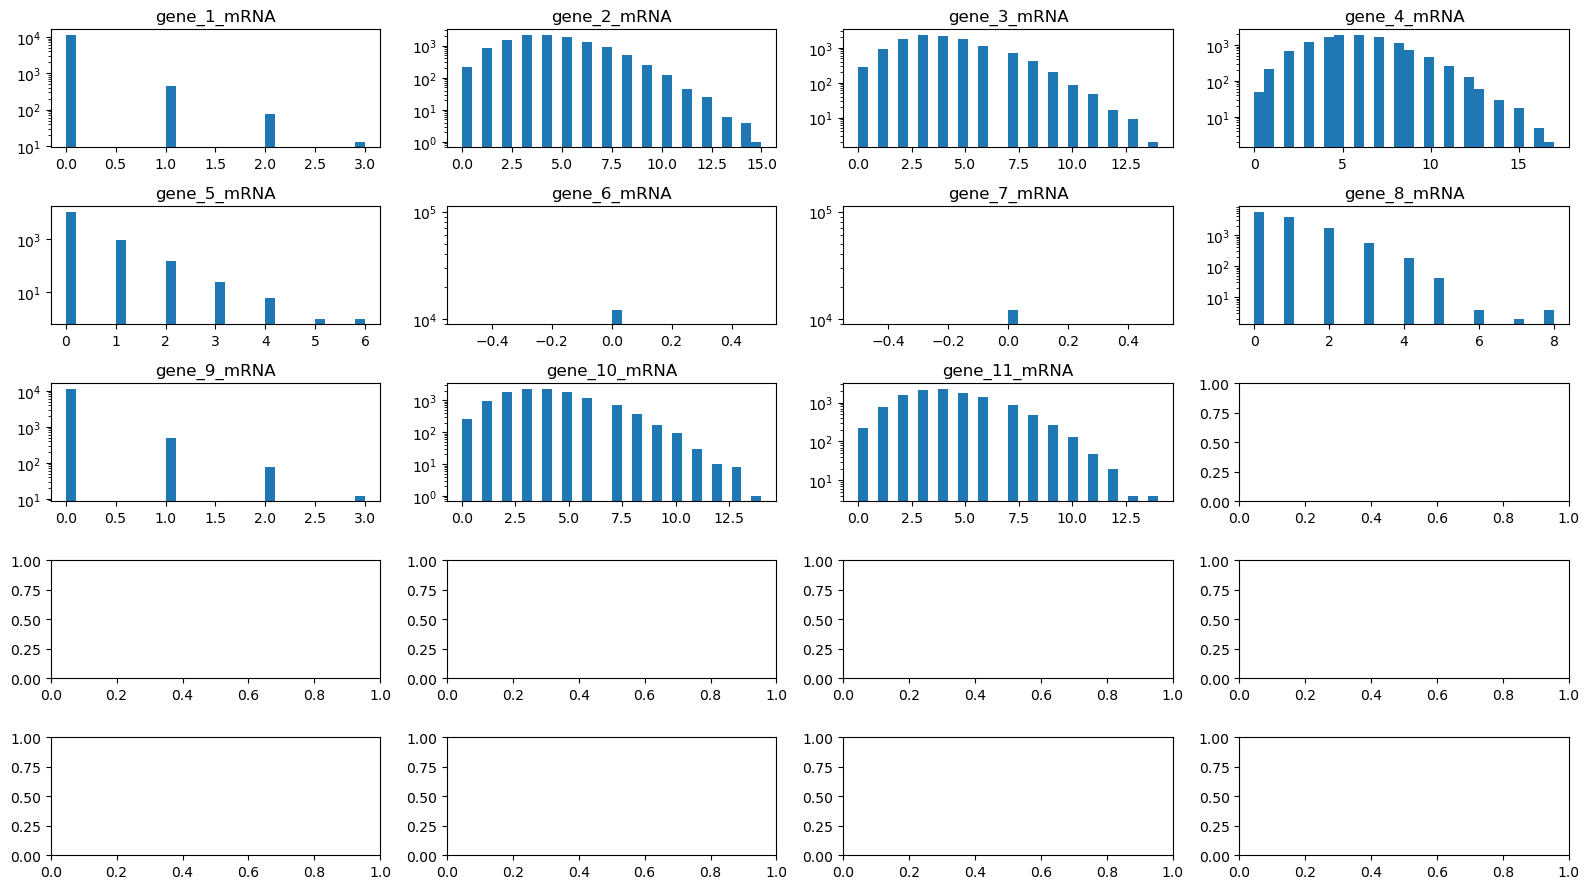

In [5]:
final_t = df[time_col].max()
final_df = df[df[time_col] == final_t]
print(final_df.shape)   # should be ~6000, one row per cell

fig, axes = plt.subplots(5, 4, figsize=(16,9))
for gene, ax in zip(gene_cols, axes.flat):
    ax.hist(final_df[gene], bins=30)
    ax.set_title(gene)
    ax.set_yscale('log')
plt.tight_layout()

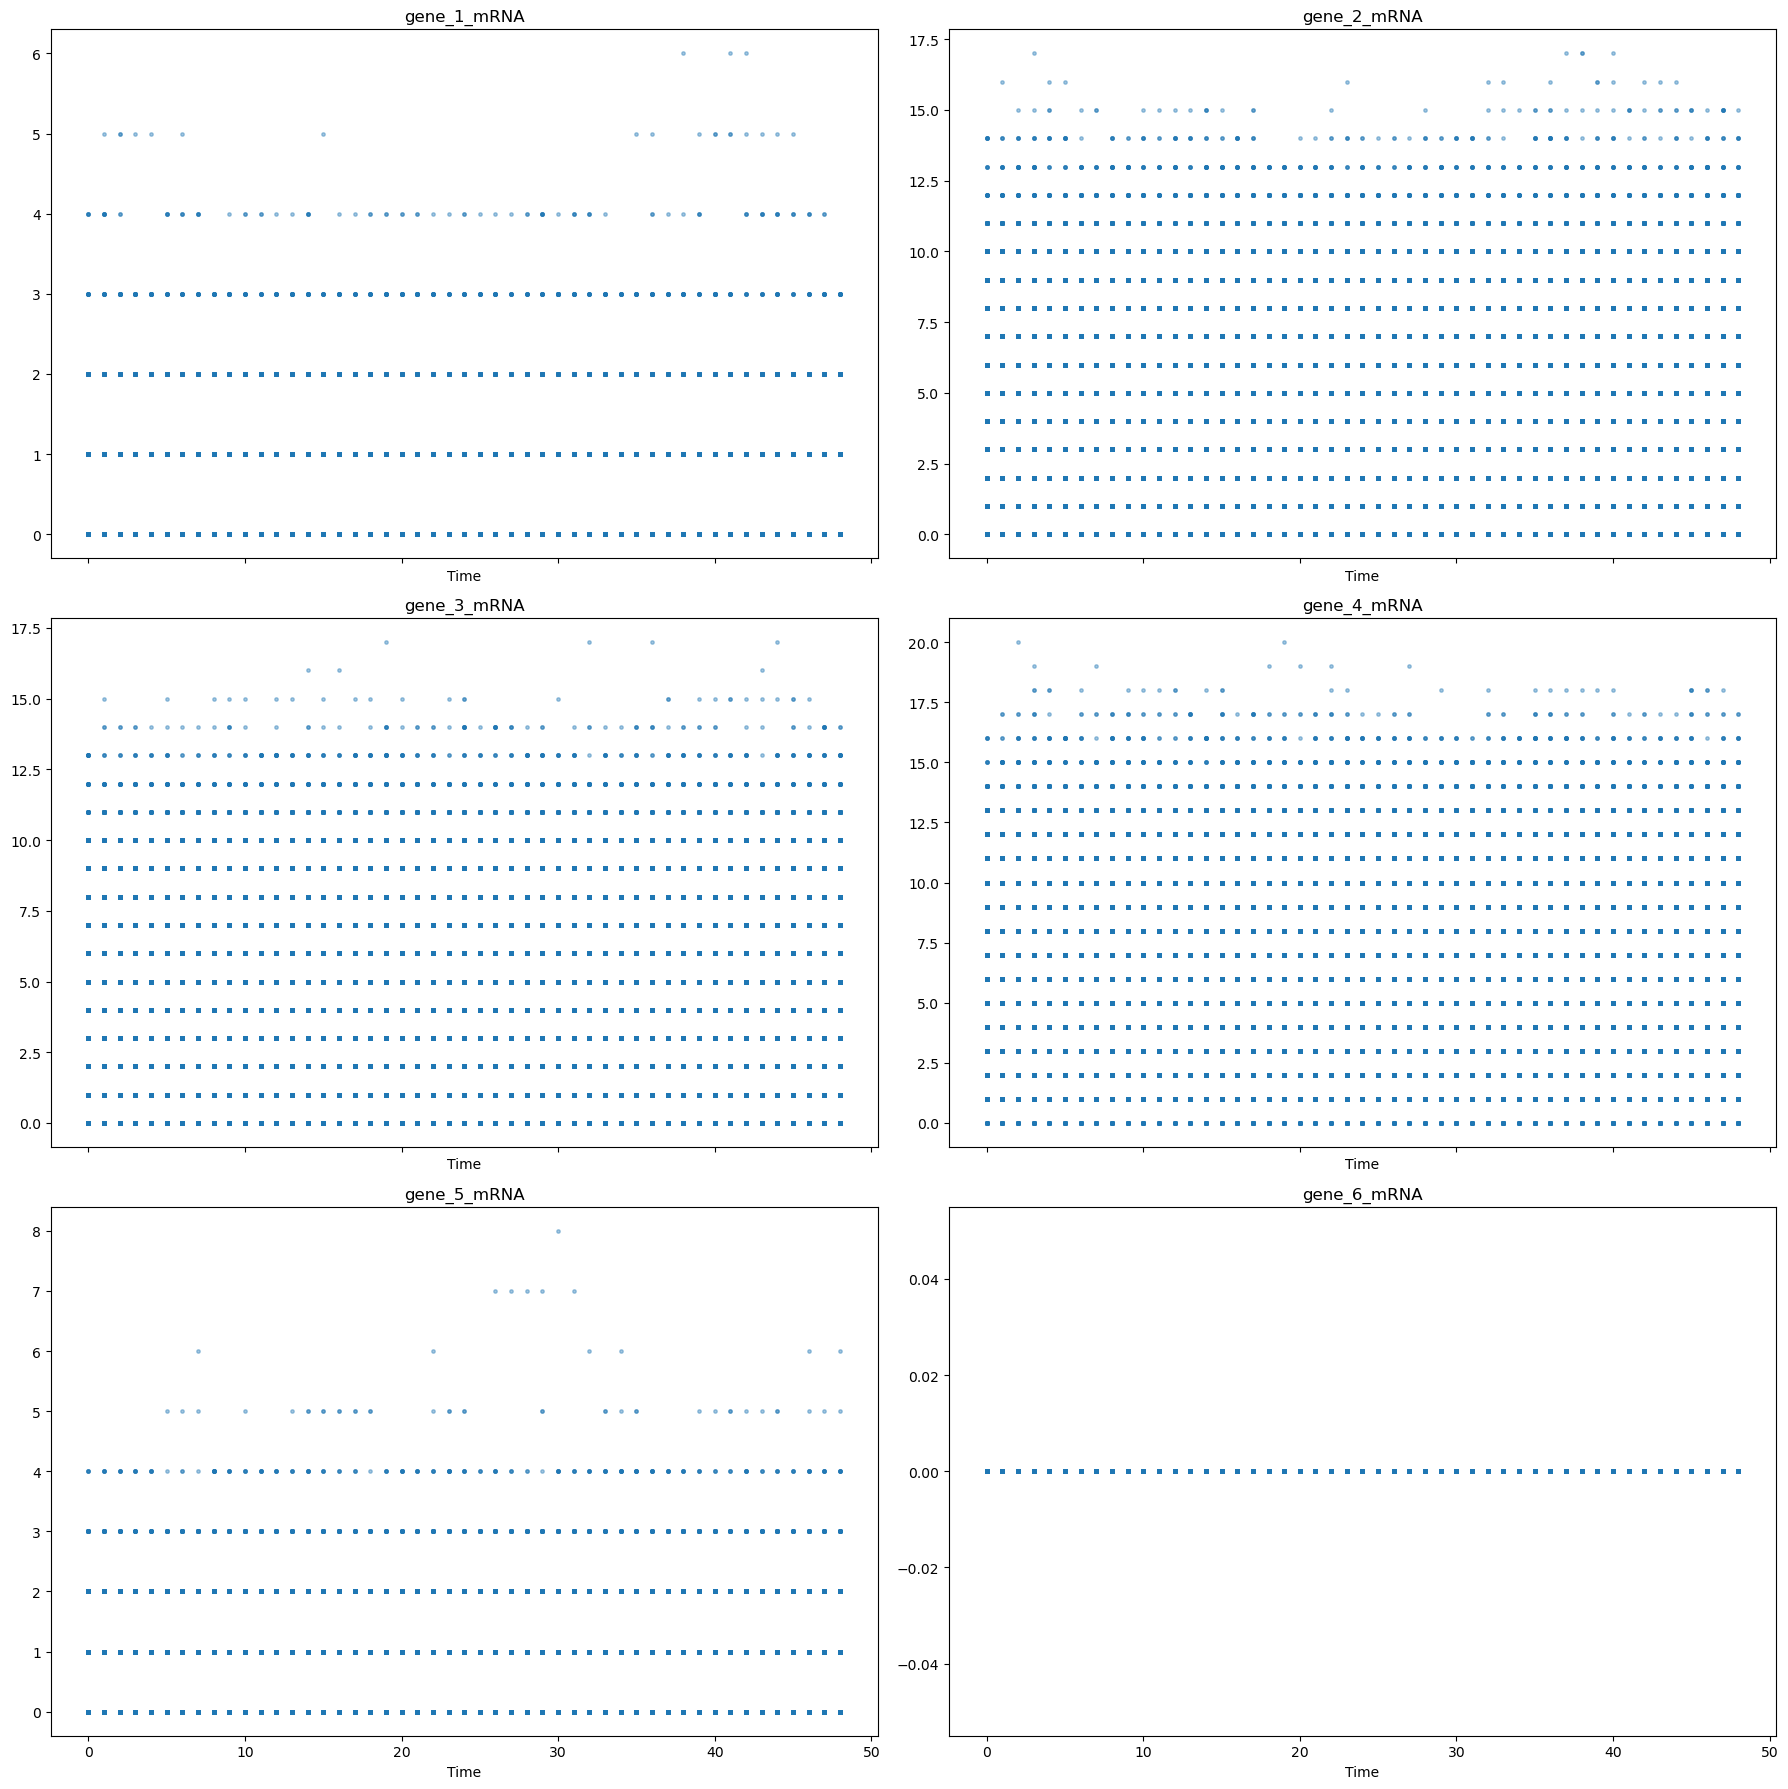

In [6]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 2, figsize=(18, 18), sharex=True)
for gene, ax in zip(gene_cols, axes.flat):
    ax.scatter(df[time_col], df[gene], s=6, alpha=0.4)
    ax.set_title(gene)
    ax.set_xlabel("Time")
plt.tight_layout()
plt.show()

/tmp/ipykernel_2832800/2543173964.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  trend = df.groupby('time_bin')[gene_cols].mean()


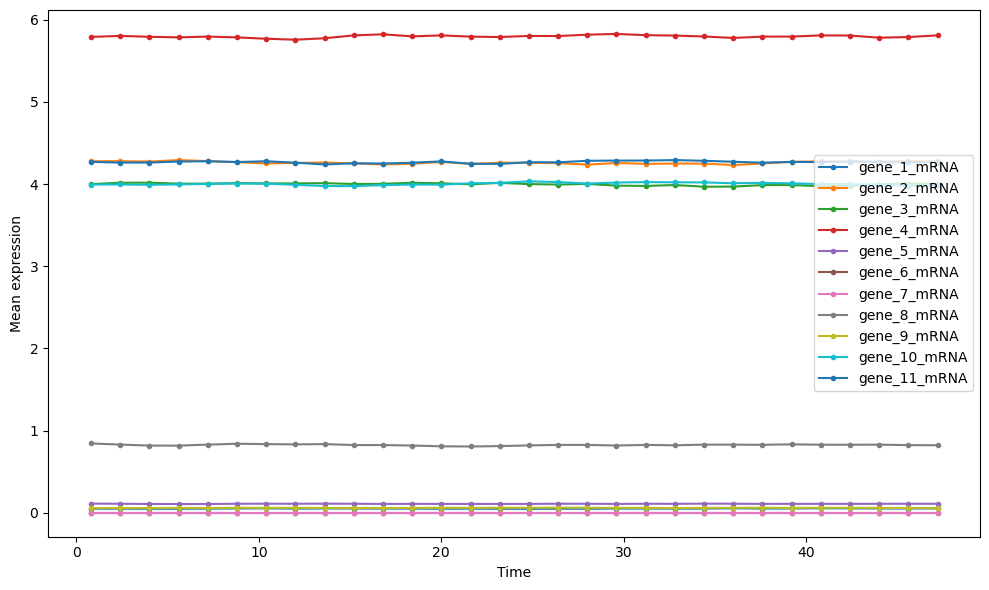

In [8]:
df['time_bin'] = pd.cut(df[time_col], bins=30)
trend = df.groupby('time_bin')[gene_cols].mean()
trend.index = trend.index.map(lambda x: x.mid)

fig, ax = plt.subplots(figsize=(10, 6))
for gene in gene_cols:
    ax.plot(trend.index, trend[gene], label=gene, marker='o', markersize=3)
ax.legend()
ax.set_xlabel("Time")
ax.set_ylabel("Mean expression")
plt.tight_layout()

Explained variance: [0.12599413 0.11782617 0.11116401 0.11112697 0.10990817]


Text(0.5, 1.0, 'PCA hexbin colored by mean time')

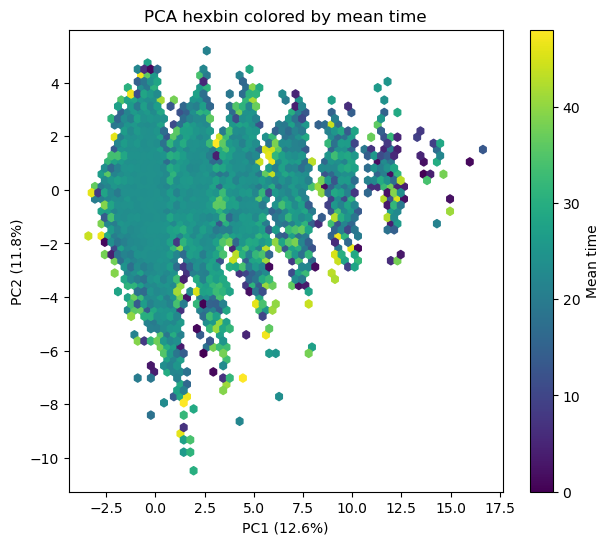

In [9]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

X = df[gene_cols].values
X_scaled = StandardScaler().fit_transform(X)  # z-score each gene

pca = PCA(n_components=min(len(gene_cols), 5))
pcs = pca.fit_transform(X_scaled)
print("Explained variance:", pca.explained_variance_ratio_)
fig, ax = plt.subplots(figsize=(7,6))
hb = ax.hexbin(pcs[:,0], pcs[:,1], C=df[time_col].values, gridsize=60, cmap='viridis', reduce_C_function=np.mean)
plt.colorbar(hb, label='Mean time')
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
ax.set_title("PCA hexbin colored by mean time")